In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.integrate import odeint
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq
cm_number = 10
cm = plt.cm.get_cmap("tab10")
colors = [cm(1. / (cm_number - 1) * i) for i in range(0, cm_number)]
import matplotlib as mpl
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset, zoomed_inset_axes
mpl.rc('font', family='Arial')
mpl.rc('font',size = 8)
mpl.rc('mathtext',fontset = 'stix')
mpl.rc('xtick', labelsize=6)
mpl.rc('ytick', labelsize=6)
# mpl.rc('xtick', labelsize=4)
# mpl.rc('ytick', labelsize=4)
mpl.rc('axes', labelsize=8)
mpl.rc('axes', labelpad=1)
mpl.rc('axes', titlesize=8)
mpl.rc('axes', linewidth=0.5)

C:\Users\TengMa\AppData\Local\Temp\ipykernel_45116\1552199352.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cm = plt.cm.get_cmap("tab10")


In [33]:
Beam_Coef = pd.read_csv("Beam_coef.csv")

In [35]:
library_matlab = [
    'u1','u1^2','u1^3','v1','v1^2','v1^3',
    'u2','u2^2','u2^3','v2','v2^2','v2^3',
    'u3','u3^2','u3^3','v3','v3^2','v3^3',
    'A*c'
]
import sys
sys.path.append("../")
import util
# importlib.reload(util)  # 重新载入

for i in range(56):
    data = np.zeros([19,3])
    for t in range(19):
        for d in range(3):
            
            data[t,d] = Beam_Coef[Beam_Coef['idx']==i]['%s__v%d'%(library_matlab[t],d+1)]
    data[-1,:] = data[-1,:]*2
    util.generate_beam_from_library(
    func_name = "Beam_POM3_%d"%i,
    out_path = "../Matcont_solver/models/MicroBeam/Beam_POM3_%d.m"%i,
    n_dof = 3,
    library = library_matlab,
    coef = data,
    tol = 1e-12
    
)

C:\Users\TengMa\AppData\Local\Temp\ipykernel_45116\2302602211.py:17: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  data[t,d] = Beam_Coef[Beam_Coef['idx']==i]['%s__v%d'%(library_matlab[t],d+1)]


In [13]:
Beam_Coef

,idx,u1__v1,u1__v2,u1__v3,u1^2__v1,u1^2__v2,u1^2__v3,u1^3__v1,u1^3__v2,u1^3__v3,...,v3__v3,v3^2__v1,v3^2__v2,v3^2__v3,v3^3__v1,v3^3__v2,v3^3__v3,A*c__v1,A*c__v2,A*c__v3
0,5,-0.300000,-2.320000e-05,0.0,0.0,0.000000e+00,-0.000002,-0.000003,-4.250000e-09,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.952000,0.002150,0.0
1,1,-0.300000,-5.440000e-05,0.0,0.0,0.000000e+00,-0.000002,0.000000,0.000000e+00,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.948000,0.002210,0.0
2,0,-0.300000,-6.020000e-05,0.0,0.0,0.000000e+00,-0.000002,0.000000,0.000000e+00,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.943000,0.002200,0.0
3,2,-0.300000,-4.840000e-05,0.0,0.0,0.000000e+00,-0.000002,-0.000002,0.000000e+00,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.943000,0.002200,0.0
4,3,-0.300000,-4.160000e-05,0.0,0.0,0.000000e+00,-0.000002,-0.000002,-3.860000e-09,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.946000,0.002180,0.0
5,4,-0.300000,-2.940000e-05,0.0,0.0,0.000000e+00,-0.000002,-0.000002,-4.230000e-09,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.953000,0.002180,0.0
6,6,-0.300000,-1.670000e-05,0.0,0.0,0.000000e+00,-0.000002,-0.000003,-5.090000e-09,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.950000,0.002110,0.0
7,7,-0.300000,-1.070000e-05,0.0,0.0,0.000000e+00,-0.000002,-0.000003,-5.100000e-09,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.952000,0.002080,0.0
8,8,-0.300000,-4.660000e-06,0.0,0.0,0.000000e+00,-0.000002,-0.000003,-5.270000e-09,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.946000,0.002060,0.0
9,9,-0.300000,-4.690000e-06,0.0,0.0,0.000000e+00,-0.000002,-0.000003,-5.230000e-09,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.947000,0.002070,0.0


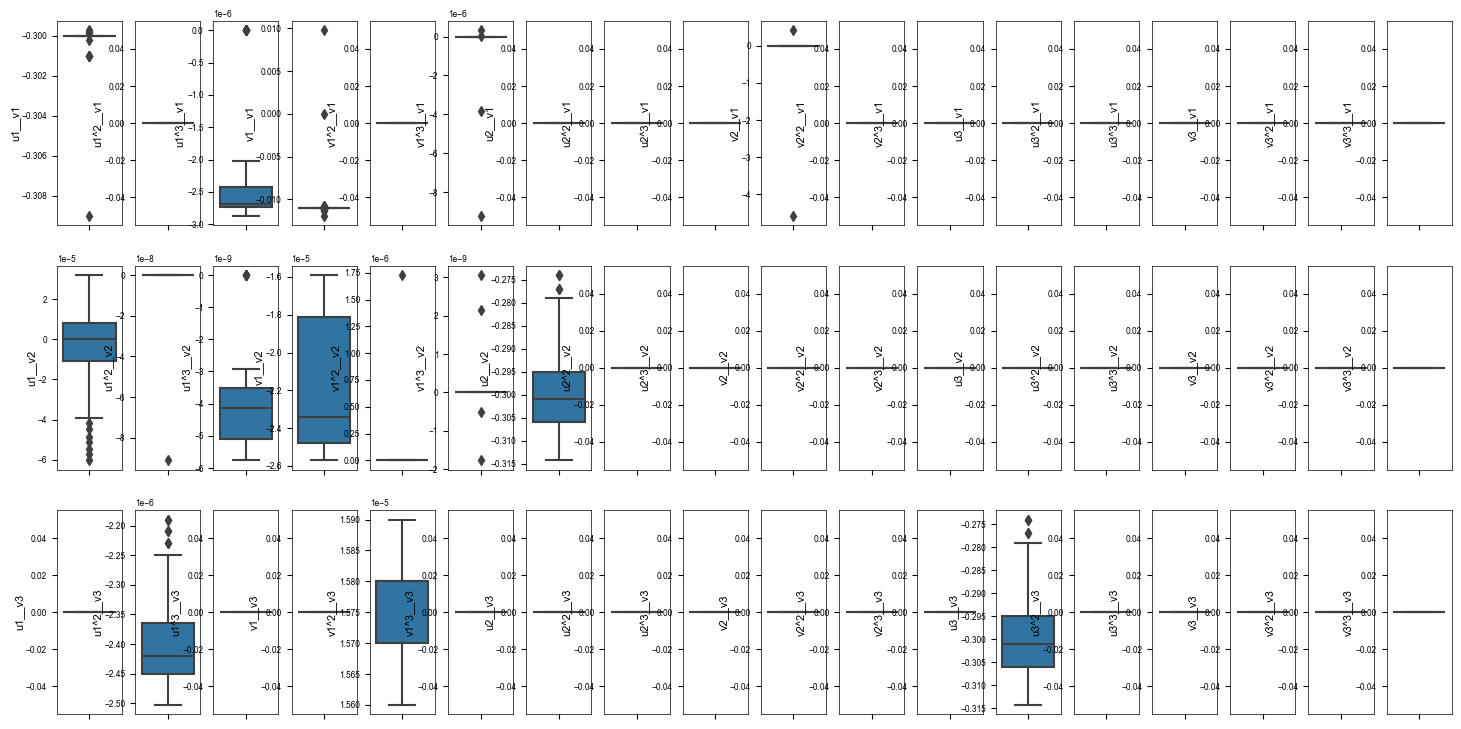

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
library_matlab = [
    'u1','u1^2','u1^3','v1','v1^2','v1^3',
    'u2','u2^2','u2^3','v2','v2^2','v2^3',
    'u3','u3^2','u3^3','v3','v3^2','v3^3',
    'A*c'
]
fig, axes = plt.subplots(3,18,figsize = (18,9))
for i in range(18):
    for j in range(3):
        ax = axes[j][i]
        data = Beam_Coef['%s__v%d'%(library_matlab[i],j+1)]
        sns.boxplot(y=data,ax = ax)
plt.show()

C:\Users\TengMa\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\TengMa\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\TengMa\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


<Axes: xlabel='u1__v1'>

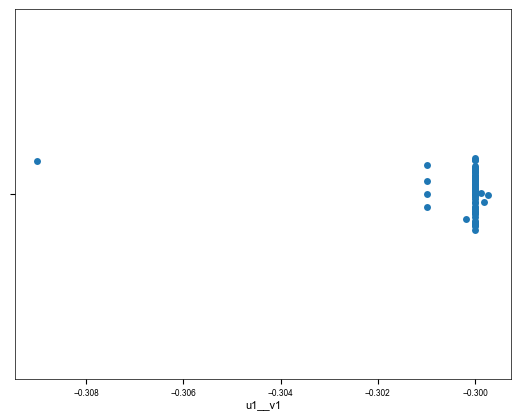

In [8]:
sns.stripplot(x=Beam_Coef['u1__v1'], jitter=True)